<a href="https://colab.research.google.com/github/Deepshika000/OIBSIP/blob/main/DataAnalytics/L1_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''TASK 2 · Customer Segmentation Analysis
Objective: Apply clustering algorithms to segment an e-commerce company's customer
base into distinct groups based on purchasing behaviour, enabling targeted marketing
strategies.'''

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [ ]:
df=pd.read_csv('E-commerce-Customer.csv')
df

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
...,...,...,...,...,...,...,...,...,...,...,...
345,446,Male,32,Miami,Silver,660.30,10,3.8,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.0,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.5,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.2,False,21,Neutral


In [ ]:
df.shape

(350, 11)

In [ ]:
df.dtypes

,0
Customer ID,int64
Gender,object
Age,int64
City,object
Membership Type,object
Total Spend,float64
Items Purchased,int64
Average Rating,float64
Discount Applied,bool
Days Since Last Purchase,int64


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [ ]:
#Cleaning Data
df.dropna(inplace=True)
#drop the 2 null value in Satisfaction Level

In [ ]:
print(df['Satisfaction Level'].isnull().sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               348 non-null    int64  
 1   Gender                    348 non-null    object 
 2   Age                       348 non-null    int64  
 3   City                      348 non-null    object 
 4   Membership Type           348 non-null    object 
 5   Total Spend               348 non-null    float64
 6   Items Purchased           348 non-null    int64  
 7   Average Rating            348 non-null    float64
 8   Discount Applied          348 non-null    bool   
 9   Days Since Last Purchase  348 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 30.2+ KB


In [ ]:
Avg=df['Items Purchased'].mean().round(2)
print('Average Purchased Value: ',Avg)

Average Purchased Value:  12.63


In [ ]:
purchase_frequency = (df['Total Spend'] / df['Items Purchased']).round(2)
purchase_frequency

,0
0,80.01
1,70.95
2,56.75
3,77.91
4,55.42
...,...
345,66.03
346,58.81
347,74.42
348,70.93


In [ ]:
# 1. Select the 3 key behavioral features for clustering
rfm_features = ['Days Since Last Purchase', 'Items Purchased', 'Total Spend']

# 2. Extract the feature matrix (X) for model input
X = df[rfm_features].copy()

# Display selected feature sample
print("Features selected for clustering:")
print(X.head())

Features selected for clustering:
   Days Since Last Purchase  Items Purchased  Total Spend
0                        25               14      1120.20
1                        18               11       780.50
2                        42                9       510.75
3                        12               19      1480.30
4                        55               13       720.40


In [ ]:
from sklearn.preprocessing import StandardScaler
# 1. Define the features selected for clustering
features = ['Days Since Last Purchase', 'Items Purchased', 'Total Spend']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the feature matrix
X_scaled = scaler.fit_transform(df[features])

# 4. Convert back to a DataFrame for easy inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# View scaled output (values will now center around 0)
print(X_scaled_df.head())

   Days Since Last Purchase  Items Purchased  Total Spend
0                 -0.120022         0.330381     0.754230
1                 -0.640260        -0.394236    -0.186319
2                  1.143413        -0.877314    -0.933192
3                 -1.086179         1.538076     1.751261
4                  2.109570         0.088842    -0.352721


In [ ]:
# Mean should be ~0 and Std Dev should be ~1
print("Scaled Means:\n", X_scaled_df.mean().round(2))
print("\nScaled Standard Deviations:\n", X_scaled_df.std().round(2))

Scaled Means:
 Days Since Last Purchase   -0.0
Items Purchased            -0.0
Total Spend                 0.0
dtype: float64

Scaled Standard Deviations:
 Days Since Last Purchase    1.0
Items Purchased             1.0
Total Spend                 1.0
dtype: float64


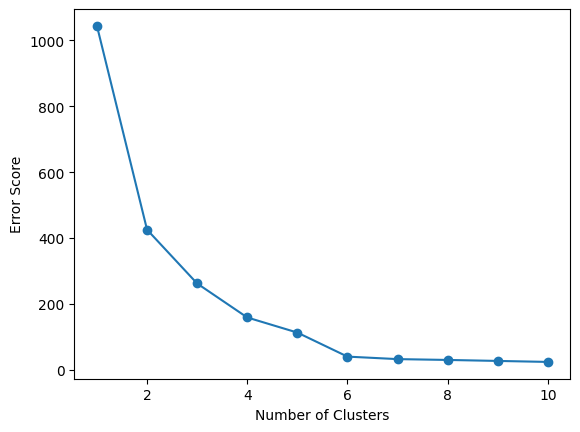

   Customer ID Membership Type  Cluster
0          101            Gold        1
1          102          Silver        1
2          103          Bronze        0
3          104            Gold        2
4          105          Silver        0


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Test cluster sizes from 1 to 10 and save their error scores
errors = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    errors.append(model.inertia_)

# 2. Draw the simple line graph
plt.plot(range(1, 11), errors, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Error Score')
plt.show()

# 3. Create 3 customer groups and save them in a new column called 'Cluster'
model = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = model.fit_predict(X_scaled)

# Look at your new grouped data
print(df[['Customer ID', 'Membership Type', 'Cluster']].head())

Text(0.5, 1.0, 'Combination 1: Total Spend vs Items Purchased')

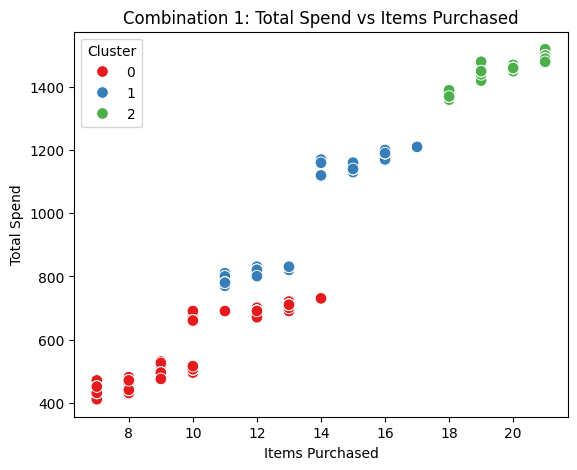

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure canvas size
plt.figure(figsize=(14, 5))

# Plot 1: Total Spend vs. Items Purchased
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='Items Purchased',
    y='Total Spend',
    hue='Cluster',
    palette='Set1',
    s=70
)
plt.title('Combination 1: Total Spend vs Items Purchased')


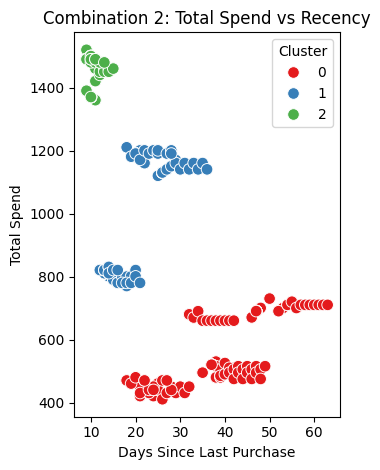

In [ ]:
# Plot 2: Total Spend vs. Days Since Last Purchase
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x='Days Since Last Purchase',
    y='Total Spend',
    hue='Cluster',
    palette='Set1',
    s=70
)
plt.title('Combination 2: Total Spend vs Recency')

plt.tight_layout()
plt.show()

In [ ]:
# Calculating mean RFM feature values per cluster
cluster_profile = df.groupby('Cluster').agg(
    Recency_Mean=('Days Since Last Purchase', lambda x: round(x.mean(), 1)),
    Frequency_Mean=('Items Purchased', lambda x: round(x.mean(), 1)),
    Monetary_Mean=('Total Spend', lambda x: round(x.mean(), 2)),
    Customer_Count=('Customer ID', 'count')
).reset_index()

print(cluster_profile)

   Cluster  Recency_Mean  Frequency_Mean  Monetary_Mean  Customer_Count
0        0          36.4             9.6         547.12             172
1        1          19.9            13.5         985.26             118
2        2          11.2            20.0        1459.77              58


In [ ]:
#describe the customer type
# Customer type 0
'''High-Value Loyalists: Frequent shoppers who spent the most money recently.
They are your primary revenue drivers and top candidates for premium membership tiers or early product access.'''

# Customer type 1
'''Inactive Shoppers: Customers who made few purchases long ago and haven't returned recently.
They require re-engagement campaigns (e.g., targeted discount codes or "we miss you" emails).'''

# Customer type 2
'''Steady / Growing Buyers: Steady customers who purchase occasionally.
They offer strong potential to convert into VIPs through cross-selling and tailored product recommendations.'''

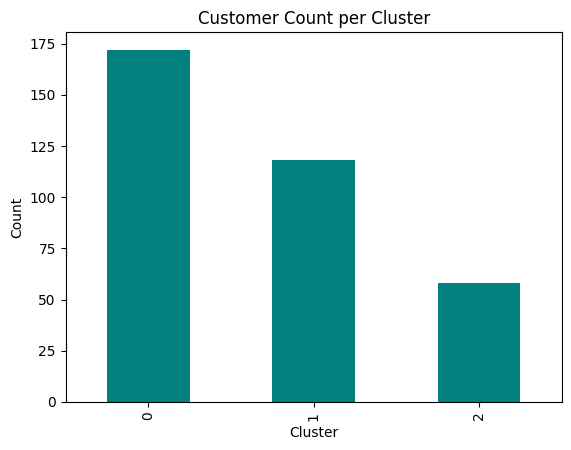

In [ ]:
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='teal', title='Customer Count per Cluster')
plt.ylabel('Count')
plt.show()

In [ ]:
#Insights section: what marketing action would you recommend for each segment?

'''From my perspective as a data analyst, segmenting our customer base using RFM metrics has transformed raw transactional data into actionable growth strategies.
By identifying distinct behaviors across our tiers, we can stop relying on broad, blanket marketing and instead target each group with
purpose—delivering exclusive perks to nurture our high-value VIPs, offering smart recommendations to boost occasional spenders,
and using targeted re-engagement offers to win back lapsed buyers. Ultimately, this tailored approach allows us to maximize marketing ROI,
improve customer retention, and drive sustainable revenue growth.'''